# Desafio 1: O perfil do Catálogo da Netflix

# Esse desafio tem como objetivo responder algumas perguntas através da
análise de dados, aprofundando o conhecimento em frequência e medidas.
Os dados que deverão ser utilizado nesse script foram baixados do kaggle,
e podem ser acessados através do link:

https://www.kaggle.com/code/shivamb/netflix-shows-and-movies-exploratory-analysis

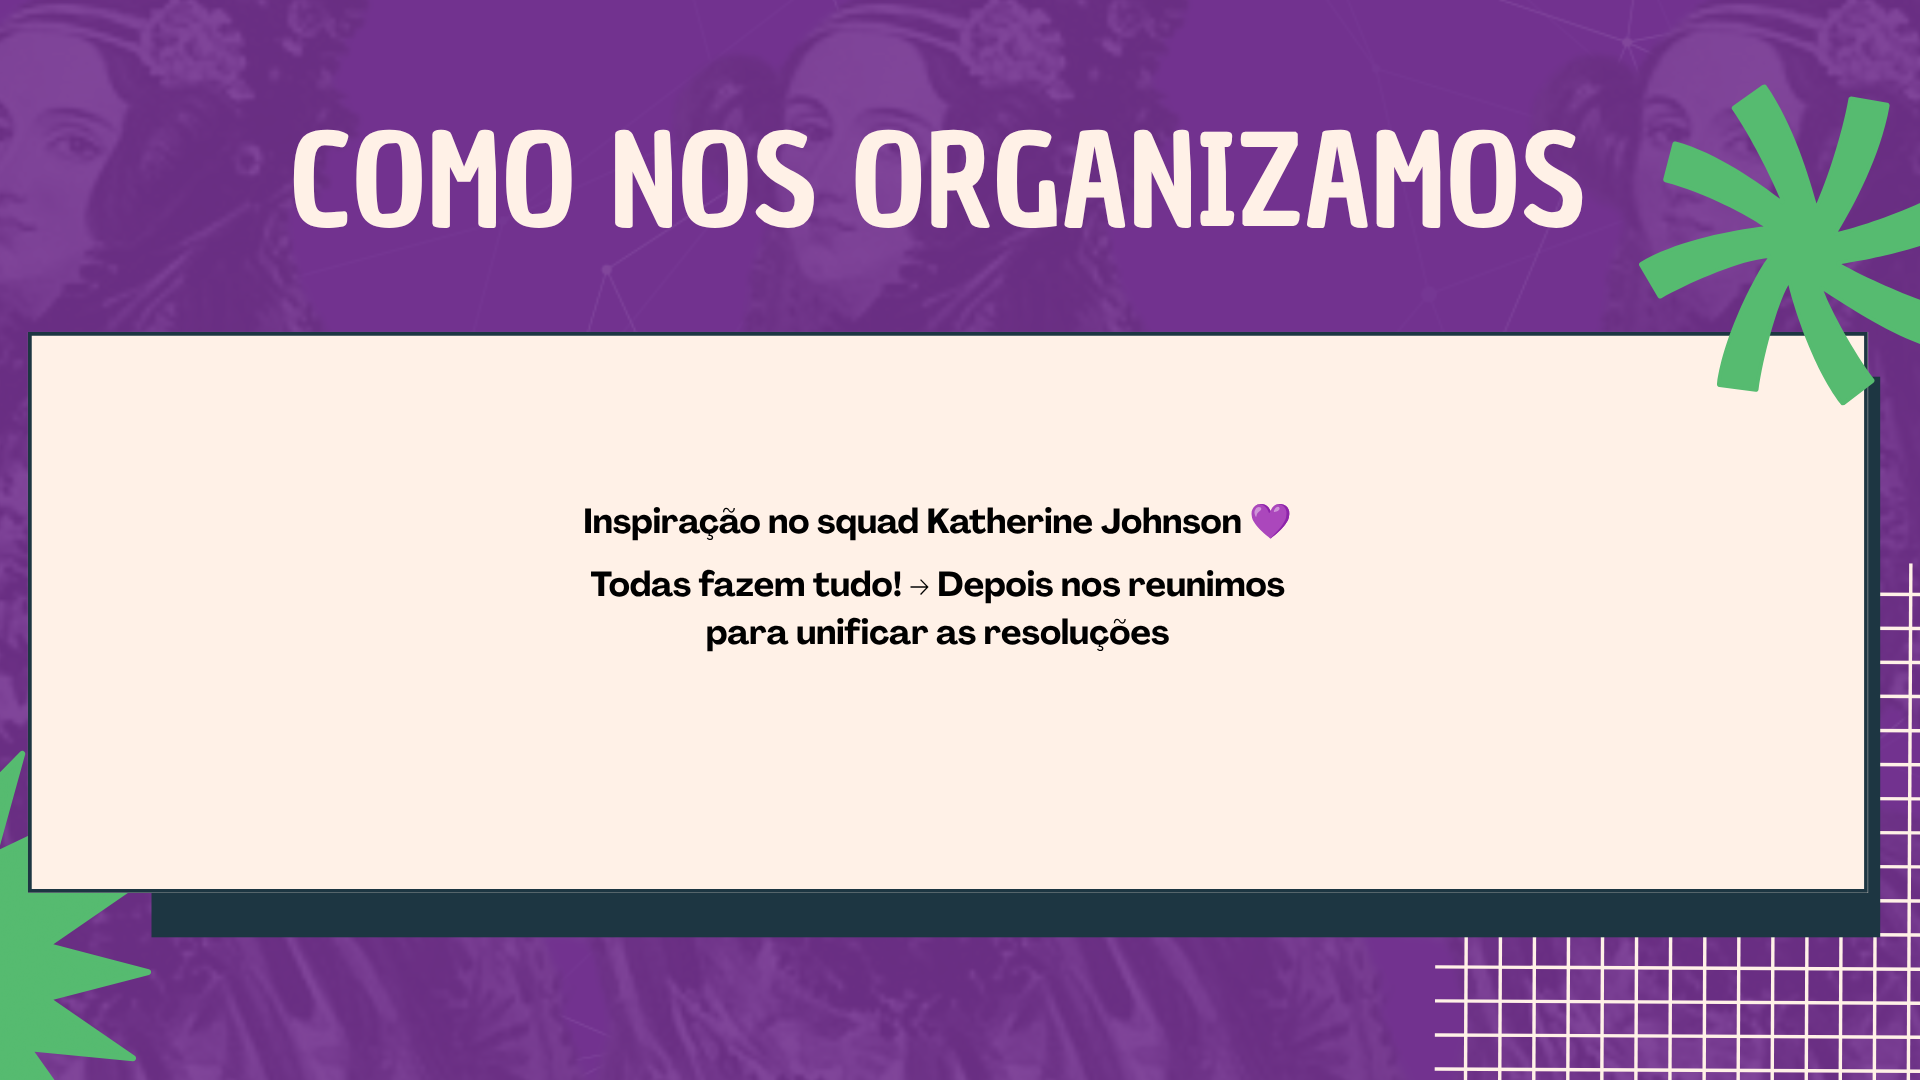

### Importações e visualização inicial:


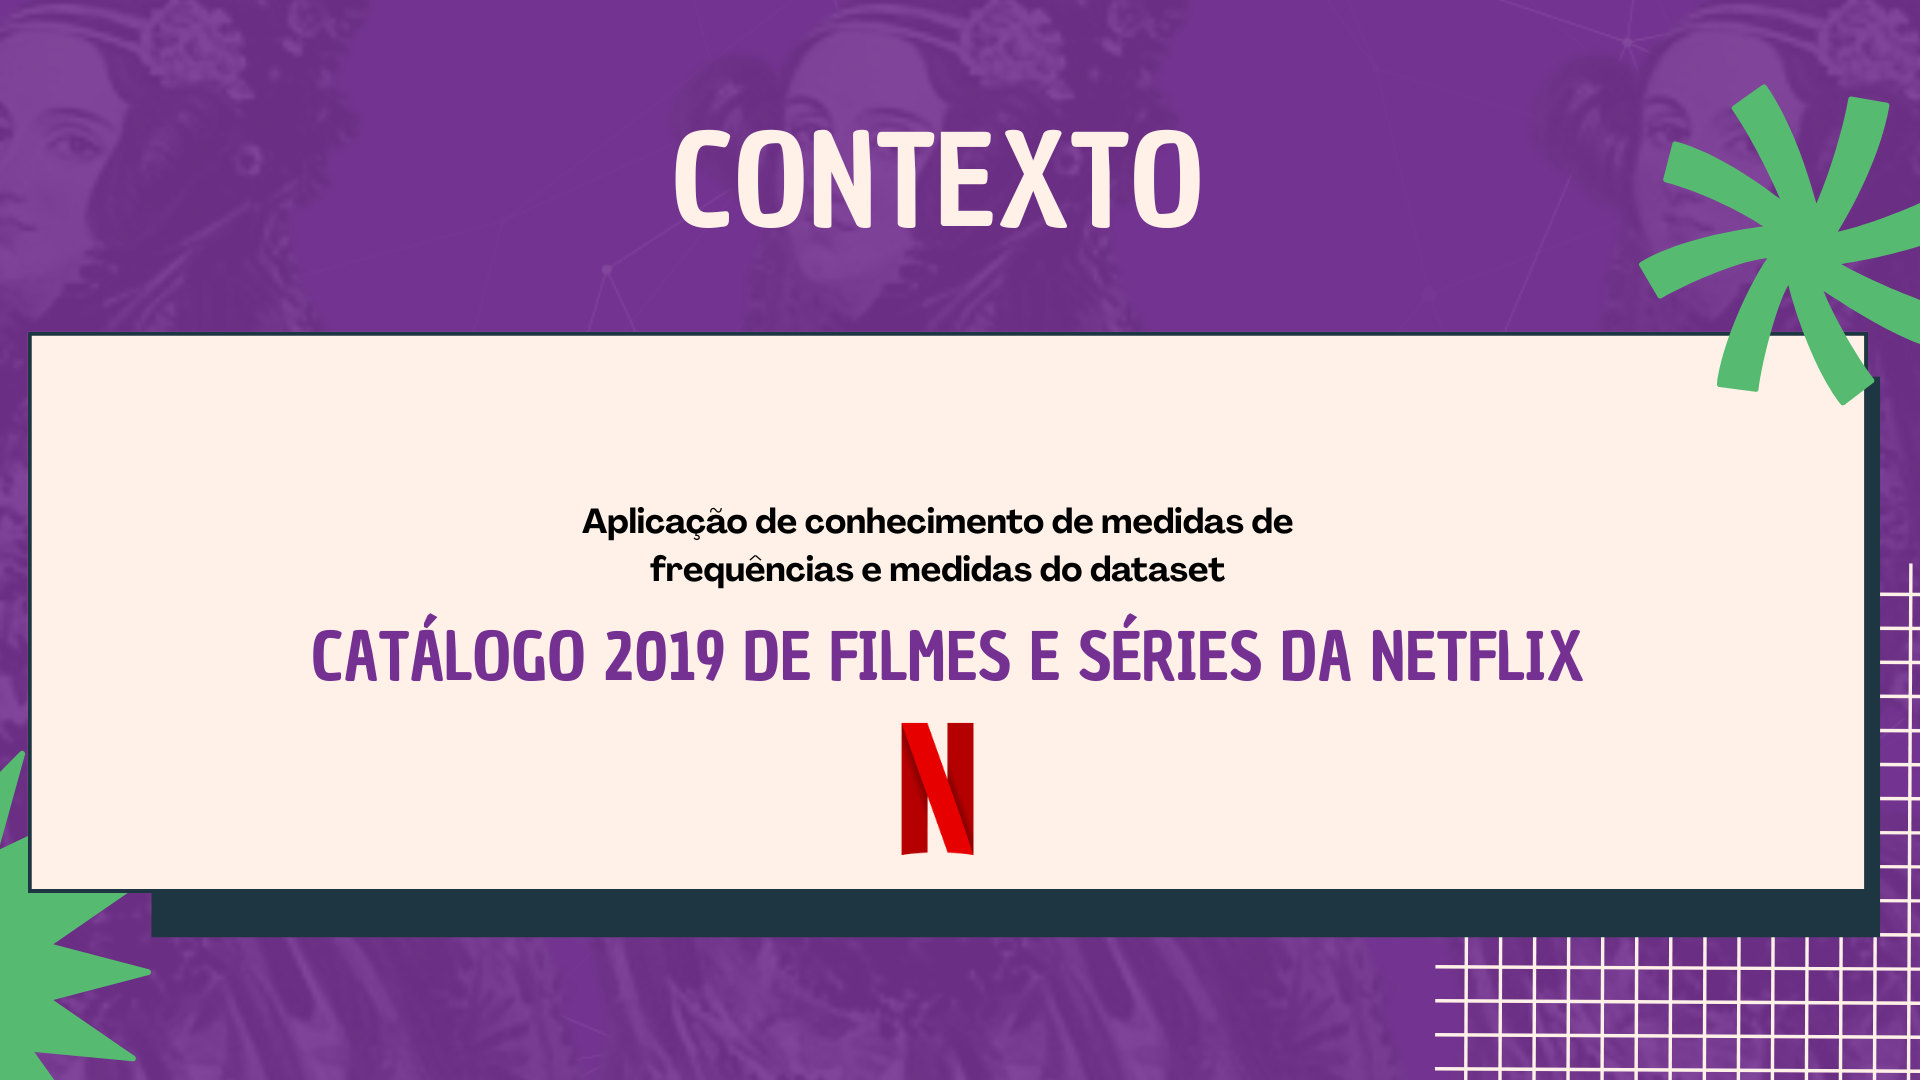

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = 'https://raw.githubusercontent.com/squad-ada-lovelace/Desafio_02-Frequencias_e_Medidas/refs/heads/main/netflix_titles_nov_2019.csv'
df = pd.read_csv(url)
headers = ["id", "titulo", "diretor", "elenco", "pais", "data_adicao", "data_lancamento", "classificacao", "duracao", "lista_generos", "descricao", "tipo"]
df.columns = headers
df.head()

,id,titulo,diretor,elenco,pais,data_adicao,data_lancamento,classificacao,duracao,lista_generos,descricao,tipo
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


### 1. Exploração inicial:


*  Quantas linhas e colunas tem o dataset?
   * O dataset possui **5837 linhas** e **12 colunas**.
* Quais são os tipos das variáveis e se há valores ausentes?
  * As variáveis são dos tipos **int** e **string**.
  * Há valores nulos nas colunas **diretor (1901)**, **elenco (556)**, **pais (427)**, **data_adicao (642)** e **classificacao (10)**.



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               5837 non-null   int64 
 1   titulo           5837 non-null   object
 2   diretor          3936 non-null   object
 3   elenco           5281 non-null   object
 4   pais             5410 non-null   object
 5   data_adicao      5195 non-null   object
 6   data_lancamento  5837 non-null   int64 
 7   classificacao    5827 non-null   object
 8   duracao          5837 non-null   object
 9   lista_generos    5837 non-null   object
 10  descricao        5837 non-null   object
 11  tipo             5837 non-null   object
dtypes: int64(2), object(10)
memory usage: 547.3+ KB


In [4]:
valores_nulos = df.isna().sum()
porcentagem_nulos = (100*valores_nulos/len(df)).round(2)

# Visualização em tabela
tabela_nulos_porcentagem = pd.concat([valores_nulos, porcentagem_nulos], axis=1, keys= ['qtdd_nulos', 'porcentagem_nulos'])
tabela_nulos_porcentagem

,qtdd_nulos,porcentagem_nulos
id,0,0.00
titulo,0,0.00
diretor,1901,32.57
elenco,556,9.53
pais,427,7.32
data_adicao,642,11.00
data_lancamento,0,0.00
classificacao,10,0.17
duracao,0,0.00
lista_generos,0,0.00


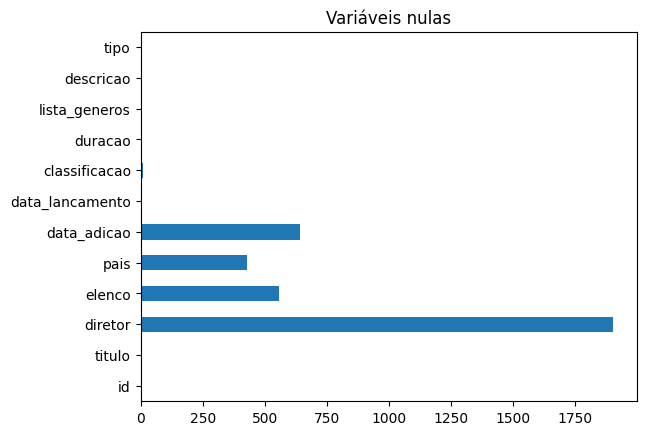

In [5]:
df.isna().sum().plot(kind='barh')
plt.title("Variáveis nulas")
plt.show()

## 2. Análises de frequência:

* Qual a proporção de filmes vs. séries no catálogo?
  * A proporção do catálogo é de **67,5% filmes** e **32,5% séries**.
* Qual o gênero mais frequente?
  * O gênero mais frequente é **International Movies**, com **1797** contagens.

In [6]:
pd.concat([df[["tipo"]].value_counts(), df[["tipo"]].value_counts(normalize=True)*100], axis=1).round(1).rename(columns={"count":"total", "proportion":"%"})

,total,%
tipo,,
Movie,3939,67.5
TV Show,1898,32.5


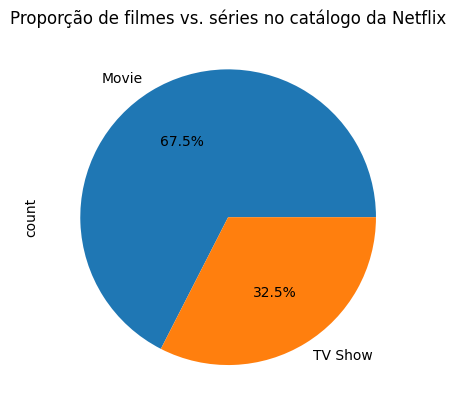

In [7]:
df["tipo"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Proporção de filmes vs. séries no catálogo da Netflix")
plt.show()

In [8]:
df_generos = df.copy()
df_generos.head()

,id,titulo,diretor,elenco,pais,data_adicao,data_lancamento,classificacao,duracao,lista_generos,descricao,tipo
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


In [9]:
df_generos["lista_generos"] = df_generos["lista_generos"].str.split(", ")
df_generos = df_generos.explode("lista_generos")
df_generos.head()

,id,titulo,diretor,elenco,pais,data_adicao,data_lancamento,classificacao,duracao,lista_generos,descricao,tipo
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,International TV Shows,Brought together by meaningful meals in the pa...,TV Show
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,Korean TV Shows,Brought together by meaningful meals in the pa...,TV Show
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,Romantic TV Shows,Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,Documentaries,"From Sierra de las Minas to Esquipulas, explor...",Movie
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,International Movies,"From Sierra de las Minas to Esquipulas, explor...",Movie


In [10]:
contagem_midia = df_generos.groupby('tipo')['lista_generos'].value_counts()
maiores_contagens = contagem_midia.groupby(level=0).head(1)
maiores_contagens

,,count
tipo,lista_generos,
Movie,International Movies,1797
TV Show,International TV Shows,966


### 3. Análises estatísticas:

* Qual a média, mediana e moda do tempo de duração dos
filmes?
  * As métricas para duração dos filmes são:
    * **Média = 98**
    * **Mediana = 97**
    * **Moda = 90**
* Qual o filme mais curto e mais longo?
  * O filme mais **curto** é **Silent**, com duração de **3 min**.
  * O filme mais **longo** é **Black Mirror: Bandersnatch**, com duração de **312 min**.

In [11]:
df_filmes = df.copy()
filmes = df_filmes["tipo"].isin(["Movie"])
df_filmes = df_filmes[filmes]
df_filmes.head()

,id,titulo,diretor,elenco,pais,data_adicao,data_lancamento,classificacao,duracao,lista_generos,descricao,tipo
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
5,81172754,Crazy people,Moses Inwang,"Ramsey Nouah, Chigul, Sola Sobowale, Ireti Doy...",Nigeria,"November 29, 2019",2018,TV-14,107 min,"Comedies, International Movies, Thrillers",Nollywood star Ramsey Nouah learns that someon...,Movie
6,81120982,I Lost My Body,Jérémy Clapin,"Hakim Faris, Victoire Du Bois, Patrick d'Assum...",France,"November 29, 2019",2019,TV-MA,81 min,"Dramas, Independent Movies, International Movies","Romance, mystery and adventure intertwine as a...",Movie


In [12]:
df_filmes["duracao"] = df_filmes["duracao"].str.replace(" min", "")
df_filmes["duracao"] = df_filmes["duracao"].astype(int)

In [13]:
duracao_filmes = df_filmes.groupby('tipo')['duracao'].agg(
    média = "mean",
    mediana = "median",
    moda = pd.Series.mode
    )

duracao_filmes.round(1)

,média,mediana,moda
tipo,,,
Movie,98.0,97.0,90


In [14]:
mask = df_filmes["duracao"] == df_filmes["duracao"].min()
df_filmes[mask][["titulo", "duracao"]]

,titulo,duracao
1185,Silent,3


In [15]:
mask = df_filmes["duracao"] == df_filmes["duracao"].max()
df_filmes[mask][["titulo", "duracao"]]

,titulo,duracao
2160,Black Mirror: Bandersnatch,312


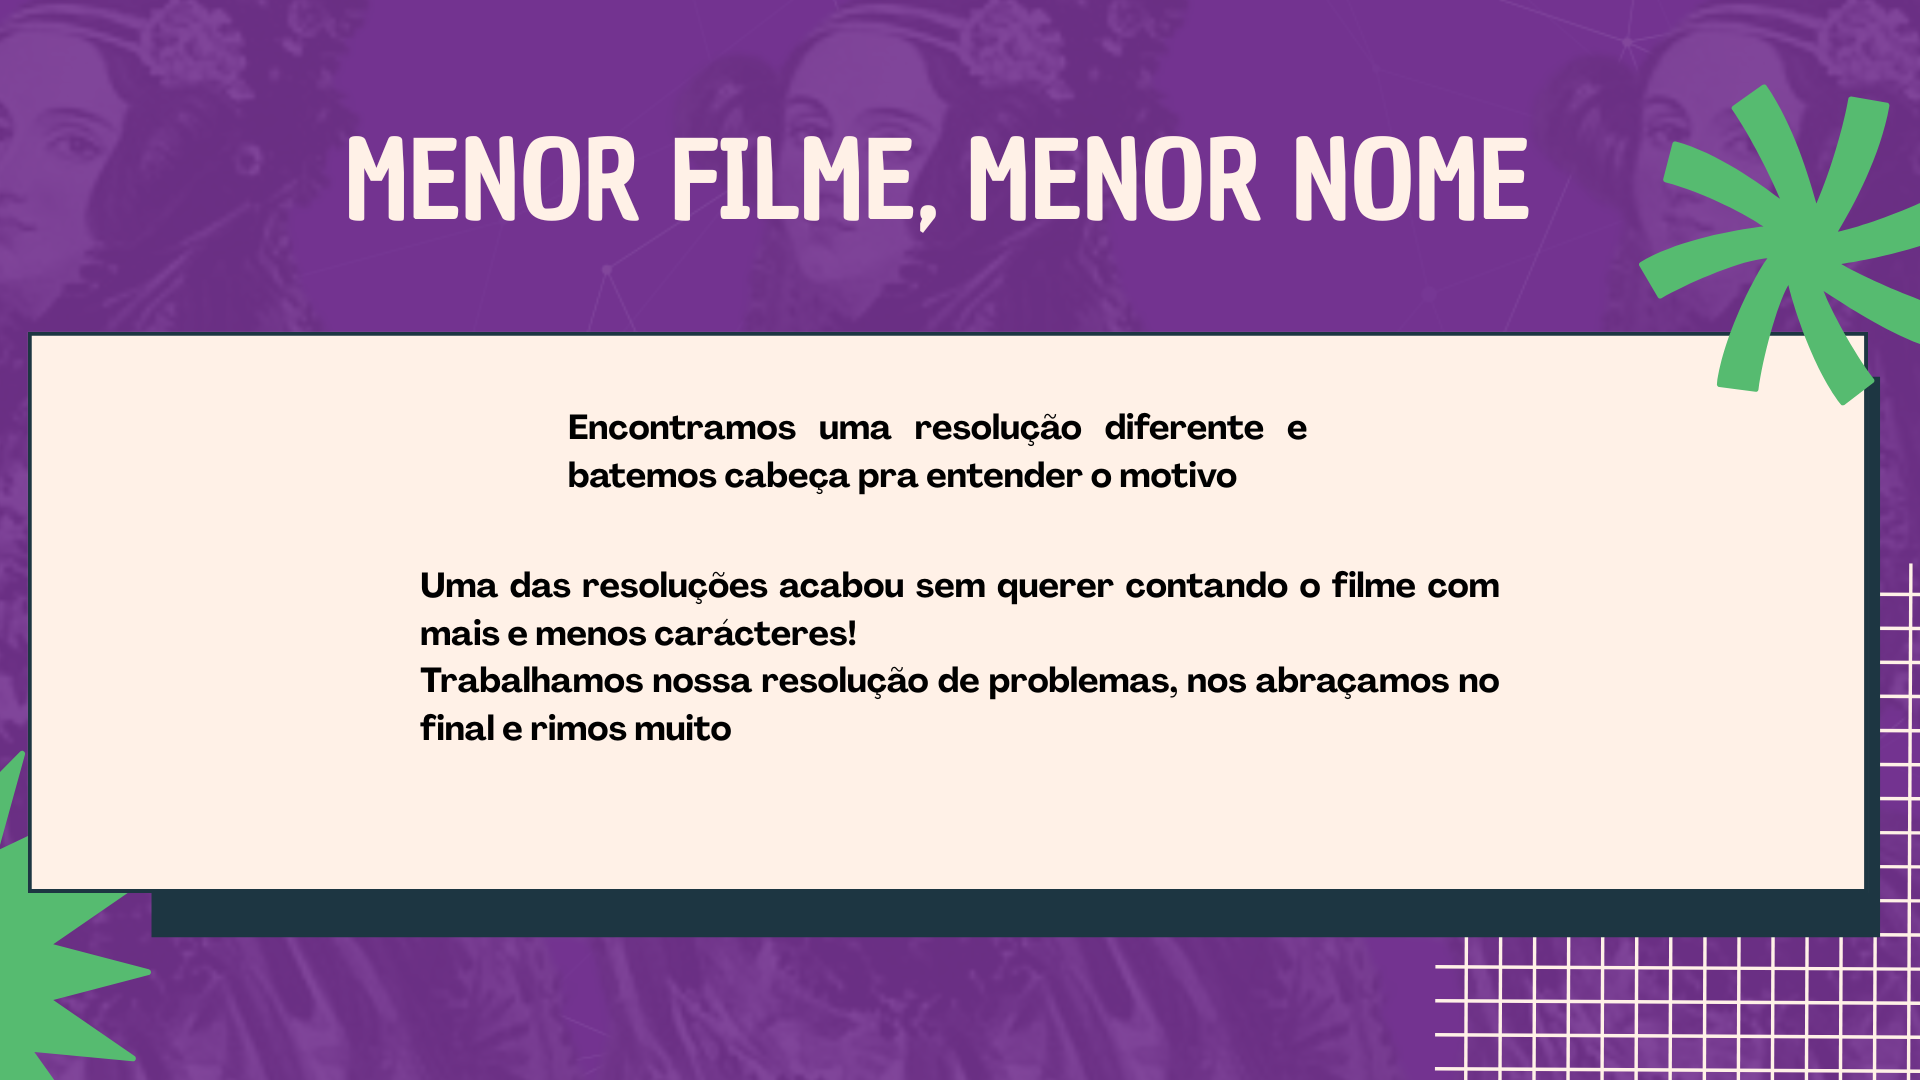

### 4. Visualização de dados:

* Criar um gráfico de barras para mostrar a quantidade de títulos
por gênero.
* Criar um histograma para analisar a distribuição da duração dos filmes.

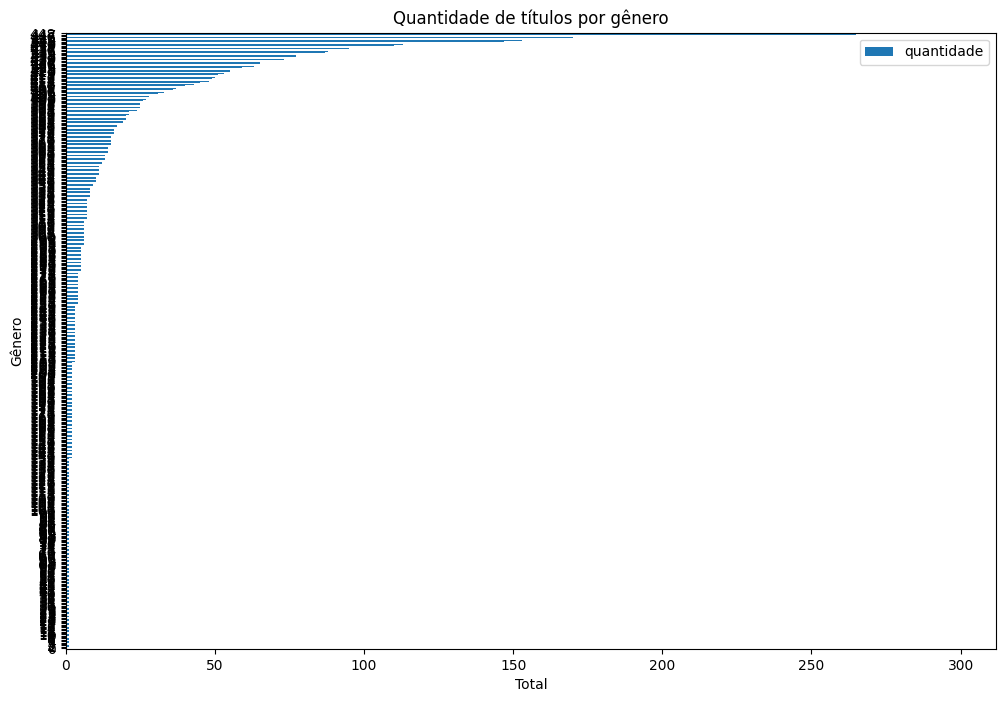

In [16]:
# Primeiro gráfico plotado sem tratamento

qtdd_por_titulo = df['lista_generos'].value_counts(ascending=True)

df_grafico = qtdd_por_titulo.reset_index()
df_grafico.columns = ['genero', 'quantidade']


# Gráfico:
df_grafico.plot(kind="barh", figsize=(12, 8))
plt.title("Quantidade de títulos por gênero")
plt.xlabel("Total")
plt.ylabel("Gênero")
plt.show()

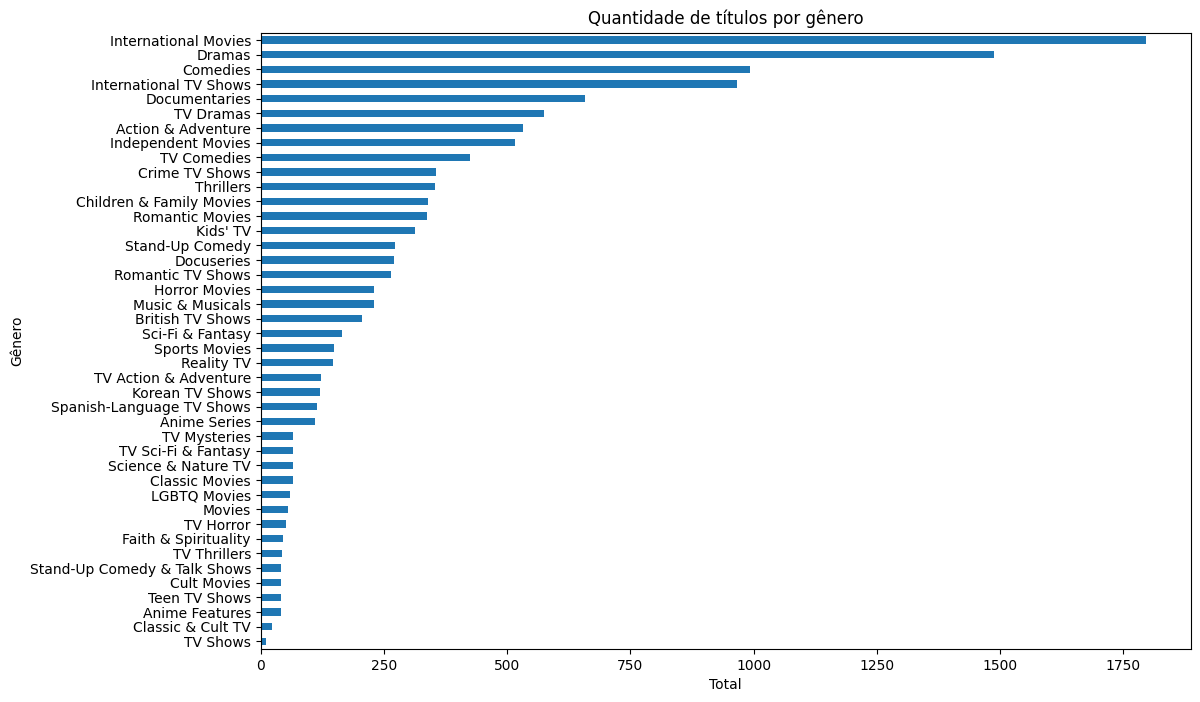

In [17]:
df_generos["lista_generos"].value_counts(ascending=True).plot(kind="barh", figsize=(12, 8))
plt.title("Quantidade de títulos por gênero")
plt.xlabel("Total")
plt.ylabel("Gênero")
plt.show()

### Outra abordagem de classificação de gêneros

In [18]:
# Classificando e agrupando gêneros (uma outra abordagem partindo dos generos originais do DF):

generos_originais = df['lista_generos'].unique()
generos_originais

array(['International TV Shows, Korean TV Shows, Romantic TV Shows',
       'Documentaries, International Movies',
       'Comedies, Dramas, International Movies',
       'Dramas, Independent Movies, International Movies', "Kids' TV",
       'Comedies, International Movies, Thrillers',
       'Dramas, International Movies',
       'Crime TV Shows, International TV Shows, Spanish-Language TV Shows',
       'Comedies, International Movies',
       'Comedies, Independent Movies, International Movies', 'Reality TV',
       'Action & Adventure, Comedies, International Movies',
       'International TV Shows, Romantic TV Shows, TV Comedies',
       'Dramas, International Movies, Thrillers', 'Docuseries',
       'Children & Family Movies, Dramas',
       'Anime Series, International TV Shows',
       'International TV Shows, Stand-Up Comedy & Talk Shows, TV Comedies',
       'TV Comedies', 'International TV Shows, TV Comedies, TV Dramas',
       'Dramas, Thrillers', 'Action & Adventure, Drama

In [19]:
# Usando somente o primeiro genero (antes da primeira vírgula)

df_grafico['genero'] = df_grafico['genero'].str.split(',').str[0]
df_grafico['genero'].unique()

array(['International TV Shows', 'Classic Movies', 'Action & Adventure',
       'Comedies', 'Classic & Cult TV', 'Children & Family Movies',
       'TV Dramas', 'Romantic TV Shows', 'Independent Movies',
       'British TV Shows', 'Stand-Up Comedy & Talk Shows', 'TV Comedies',
       'Dramas', 'TV Sci-Fi & Fantasy', 'Cult Movies', 'Sports Movies',
       'Anime Features', 'International Movies', 'Horror Movies',
       'Crime TV Shows', 'Reality TV', 'Docuseries', 'Anime Series',
       'Sci-Fi & Fantasy', 'Spanish-Language TV Shows',
       'TV Action & Adventure', "Kids' TV", 'TV Horror', 'Documentaries',
       'Romantic Movies', 'Music & Musicals', 'TV Shows', 'Thrillers',
       'Movies', 'Stand-Up Comedy'], dtype=object)

In [20]:
# Mapeando gêneros originais para novos gêneros de acordo com o "entendimento do negócio"

mapeamento_generos = {
    'Comedies': 'Comédia',
    'TV Comedies': 'Comédia',
    'Stand-Up Comedy': 'Stand-Up',
    'Stand-Up Comedy & Talk Shows': 'Stand-Up',
    "Kids' TV": 'Infantil',
    'Children & Family Movies': 'Infantil',
    'Action & Adventure': 'Ação',
    'TV Action & Adventure': 'Ação',
    'Anime Series': 'Anime',
    'Anime Features': 'Anime',
    'Documentaries': 'Documentário e Reality',
    'Reality TV': 'Documentário e Reality',
    'Docuseries': 'Documentário e Reality',
    'Dramas': 'Drama',
    'TV Dramas': 'Drama',
    'Sci-Fi & Fantasy': 'Fantasia e Sci-Fi',
    'TV Sci-Fi & Fantasy': 'Fantasia e Sci-Fi',
    'International TV Shows': 'Internacional',
    'British TV Shows': 'Internacional',
    'Spanish-Language TV Shows': 'Internacional',
    'International Movies': 'Internacional',
    'Classic Movies': 'Clássico e Cult',
    'Classic & Cult TV': 'Clássico e Cult',
    'Cult Movies': 'Clássico e Cult',
    'Music & Musicals': 'Musical',
    'Horror Movies': 'Terror e Horror',
    'Thrillers': 'Terror e Horror',
    'TV Horror': 'Terror e Horror',
    'Romantic Movies': 'Romance',
    'Romantic TV Shows': 'Romance',
    'Crime TV Shows': 'Policial',
    'Independent Movies': 'Independente',
    'Movies': 'Outros',
    'TV Shows': 'Outros',
    'Sports Movies': 'Outros'
}

In [21]:
# Aplicando os generos agrupados numa nova coluna
df_grafico['generos_agrupados'] = df_grafico['genero'].map(mapeamento_generos)
df_grafico['generos_agrupados'].value_counts()

,count
generos_agrupados,
Internacional,81
Ação,67
Comédia,51
Infantil,42
Drama,41
Documentário e Reality,38
Clássico e Cult,34
Policial,32
Anime,20


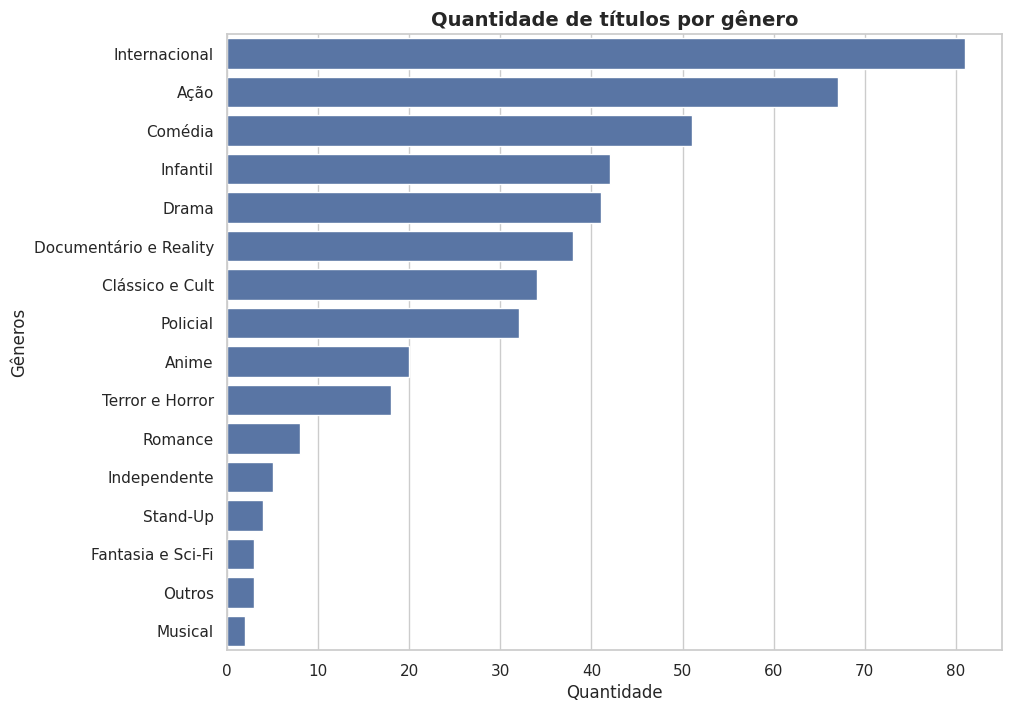

In [22]:
# Novo gráfico! O barplot deixou de ser adequado: usar o countplot para pegar os valores iguais ao do value_count()
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
sns.countplot(df_grafico, y= 'generos_agrupados', order = df_grafico['generos_agrupados'].value_counts().index)
plt.title('Quantidade de títulos por gênero', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade', fontsize=12)
plt.ylabel('Gêneros', fontsize=12)
plt.show()

### Histograma

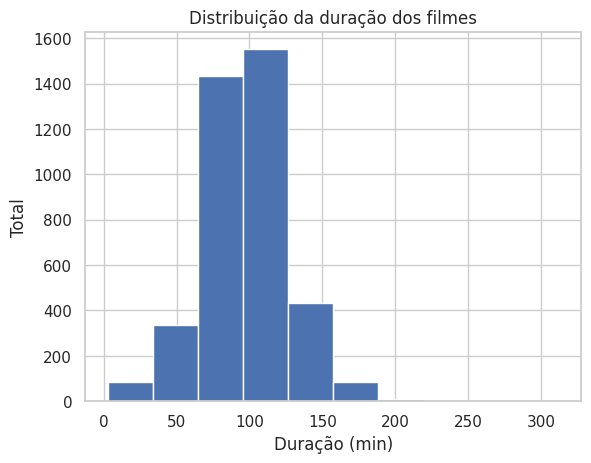

In [23]:
df_filmes["duracao"].plot(kind='hist', edgecolor="white")
plt.title("Distribuição da duração dos filmes")
plt.xlabel("Duração (min)")
plt.ylabel("Total")
plt.show()

### 📊 Atividade extra:

* Quais são os 5 países que possuem mais produções no catálogo?
  * Os 5 países com mais produções no catálogo da netflix são **Estados Unidos**, **India**, **Reino Unido**, **Canadá** e **França**.

In [24]:
top_5 = df.copy()
top_5.head()

,id,titulo,diretor,elenco,pais,data_adicao,data_lancamento,classificacao,duracao,lista_generos,descricao,tipo
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


In [25]:
top_5["pais"] = top_5["pais"].str.split(", ")
top_5 = top_5["pais"].explode().value_counts().head()
top_5

,count
pais,
United States,2420
India,753
United Kingdom,558
Canada,300
France,255


## Dificuldades e facilidades

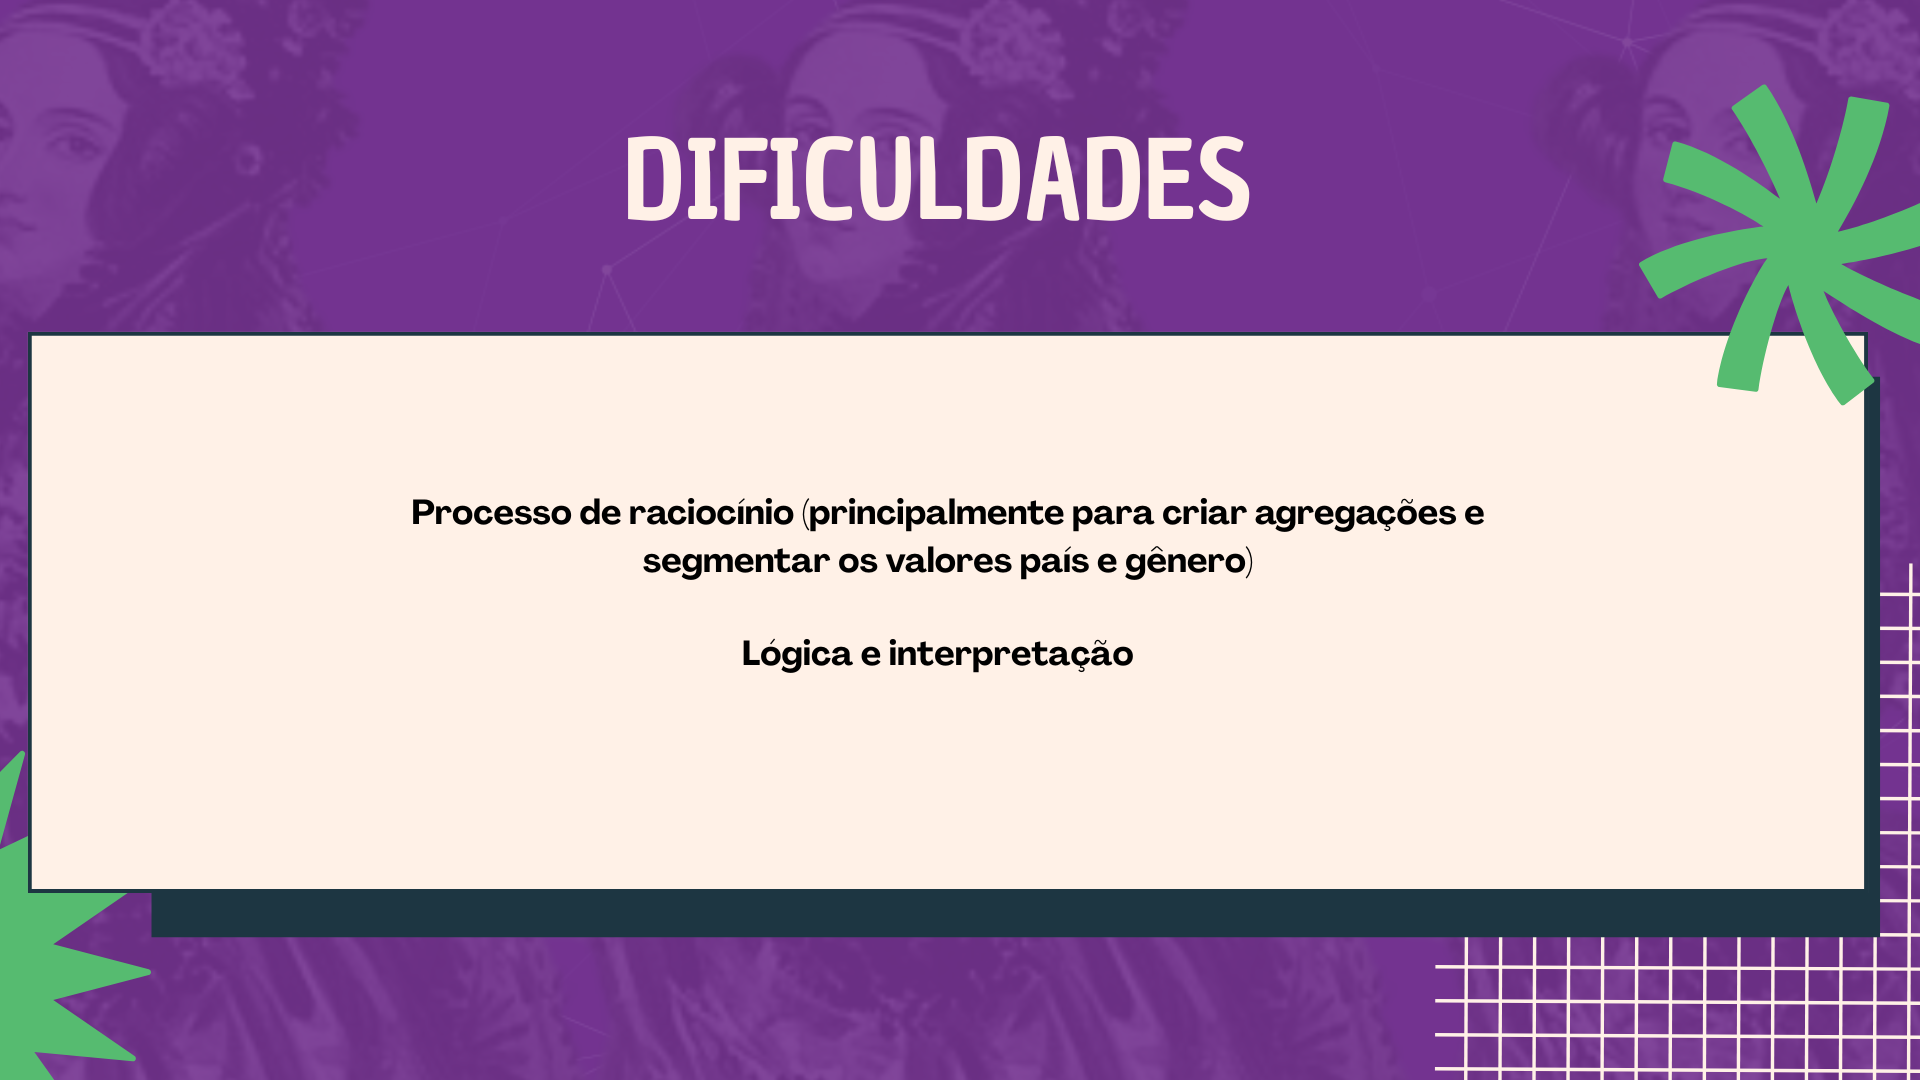

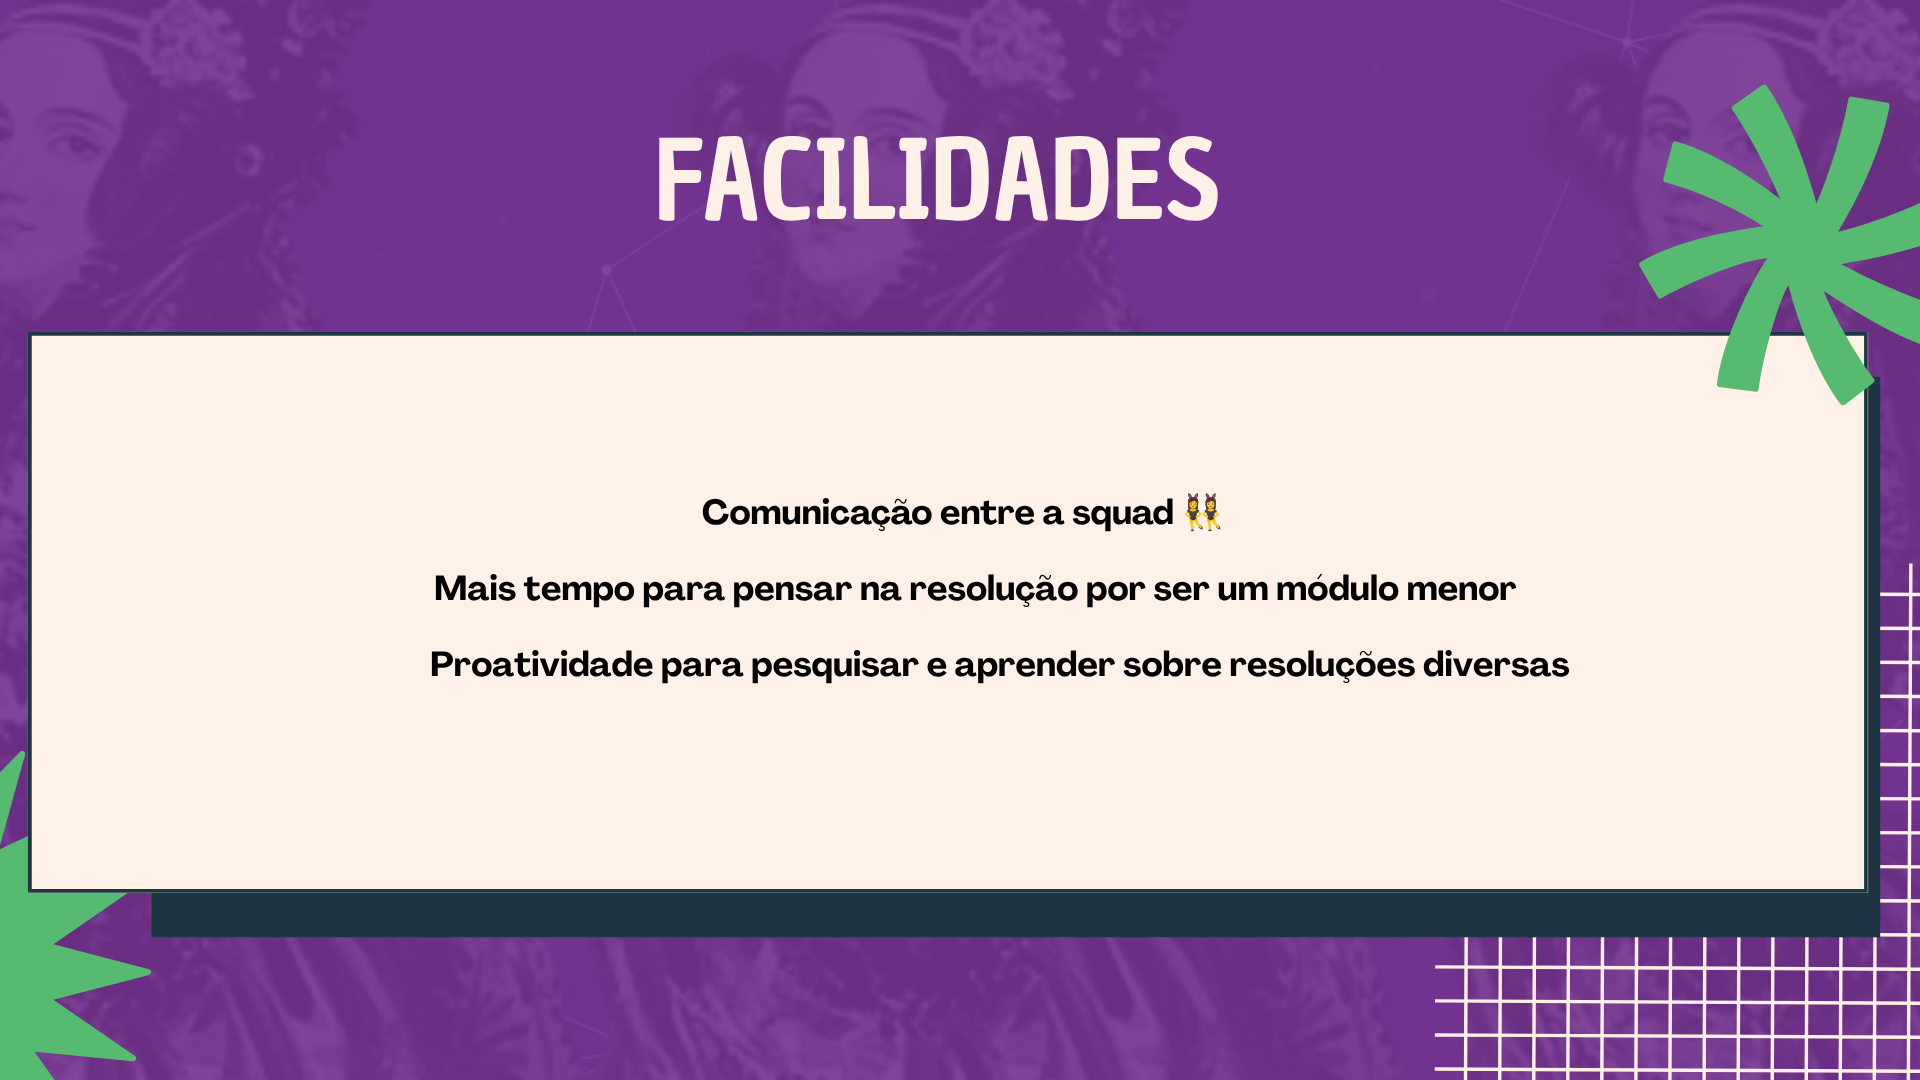